Today's topics:
* computing a new column from old ones
* storing it in the table
* bar charts
* colors, line styles and markers
* dividing by zero
* `np.linspace` and `np.arange`
* `np.exp`
* two panels in one figure

# Why is the mirror gold?

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/Gold-coated_Primary_Mirror_Segment_%284976532481%29.jpg/960px-Gold-coated_Primary_Mirror_Segment_%284976532481%29.jpg" alt="An engineer in a white cleanroom suit inspecting a row of six hexagonal telescope mirror segments, each with a bright gold reflective surface" width=520/>

Photo by NASA's James Webb Space Telescope, public domain, [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Gold-coated_Primary_Mirror_Segment_(4976532481).jpg).

Last time we said gold makes a good infrared mirror because its $k$ is large.
Today we'll use $n$ and $k$ to calculate reflectance, penetration depth and transmission.

In [1]:
#@title Find the data file and split it by material (click ▶ to run) { display-mode: "form" }
import os

import pandas as pd

_file = 'optical_constants.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)
source = _local if _local else _github

try:
    _table = pd.read_csv(source)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# Picking out one material's rows is boolean indexing, which is L11. Everything
# else in today's lecture happens in the open.
materials = {
    name: _table[_table['material'] == name].sort_values('wavelength_um').reset_index(drop=True)
    for name in ('silicon', 'BK7', 'fused_silica', 'gold')
}

print(f'Ready. Four materials split out of {_file}:')
for _name, _frame in materials.items():
    print(f'  {_name:14s} {len(_frame):2d} wavelengths')

Ready. Four materials split out of optical_constants.csv:
  silicon        11 wavelengths
  BK7            13 wavelengths
  fused_silica   10 wavelengths
  gold           13 wavelengths


The same four materials and the same dictionary as last time.

In [2]:
si = materials['silicon']
au = materials['gold']
bk7 = materials['BK7']
silica = materials['fused_silica']

display(au.head())

,material,wavelength_um,n,k
0,gold,0.1879,1.28,1.188
1,gold,0.2033,1.33,1.277
2,gold,0.2214,1.30,1.427
3,gold,0.2426,1.32,1.577
4,gold,0.2689,1.38,1.803


# A new column from two old ones

We can calculate a new column from columns already in the table.
At normal incidence, the fraction of light reflected from a surface is

$$R = \frac{(n-1)^2 + k^2}{(n+1)^2 + k^2}$$

In [3]:
n = au['n']
k = au['k']

R_gold = ((n - 1)**2 + k**2) / ((n + 1)**2 + k**2)

print(R_gold)

0     0.225386
1     0.246419
2     0.290231
3     0.329041
4     0.380833
5     0.386111
6     0.386595
7     0.406732
8     0.401478
9     0.882363
10    0.974463
11    0.979520
12    0.980989
dtype: float64


`R_gold` has one reflectance for each wavelength in `au`.
The arithmetic is elementwise, just as it is for NumPy arrays.

## Storing it in the table

Column assignment stores the result in the table.

In [4]:
au['R'] = R_gold

display(au.head())

,material,wavelength_um,n,k,R
0,gold,0.1879,1.28,1.188,0.225386
1,gold,0.2033,1.33,1.277,0.246419
2,gold,0.2214,1.30,1.427,0.290231
3,gold,0.2426,1.32,1.577,0.329041
4,gold,0.2689,1.38,1.803,0.380833


Assigning to a name that doesn't exist yet adds a column.
Assigning to one that does replaces it.

> Note: `pd.to_numeric` did not change the table in Lecture 8 because we did not assign its result back to a column.

## The same expression on four materials

Let's write it three more times and put all four on one figure.

In [5]:
R_silicon = ((si['n'] - 1)**2 + si['k']**2) / ((si['n'] + 1)**2 + si['k']**2)
R_bk7 = ((bk7['n'] - 1)**2 + bk7['k']**2) / ((bk7['n'] + 1)**2 + bk7['k']**2)
R_silica = ((silica['n'] - 1)**2 + silica['k']**2) / ((silica['n'] + 1)**2 + silica['k']**2)

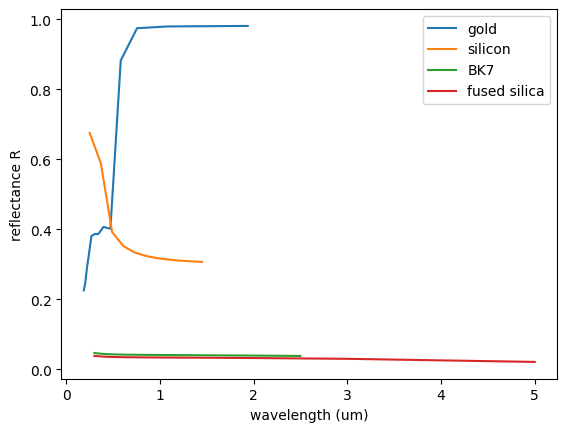

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, label='gold')
ax.plot(si['wavelength_um'], R_silicon, label='silicon')
ax.plot(bk7['wavelength_um'], R_bk7, label='BK7')
ax.plot(silica['wavelength_um'], R_silica, label='fused silica')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')
ax.legend()

Gold reaches 98% reflectance in the infrared.

The glasses are near 4%, which is why you can see through a window and still catch your reflection in it at night.

> Note: the lines stop at different places because each material was measured over its own range of wavelengths.

## Comparing four numbers: `ax.bar`

To compare the highest measured reflectance of each material, collect four maxima and plot one bar per material.

In [7]:
import numpy as np

names = ['gold', 'silicon', 'BK7', 'fused silica']
peaks = [np.max(R_gold), np.max(R_silicon), np.max(R_bk7), np.max(R_silica)]

print(peaks)

[np.float64(0.9809892609988491), np.float64(0.675666988889403), np.float64(0.046888450333547875), np.float64(0.038445242931688356)]


`ax.bar` takes category labels and their heights.

Text(0, 0.5, 'highest reflectance')

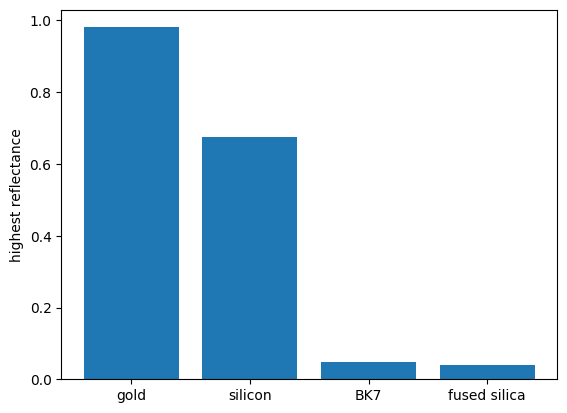

In [8]:
fig, ax = plt.subplots()
ax.bar(names, peaks)
ax.set_ylabel('highest reflectance')

Use bars for values attached to categories.
A line would imply an order and meaningful intervals between the four materials.

Gold reaches 98%, silicon 68%, and the two glasses under 5%.

## Counting into bins: `ax.hist`

A **histogram** groups an array of observations into bins and counts how many fall in each one.
We used `plt.hist` in Lecture 6; the axes form is `ax.hist`.
Read the full table so the histogram includes all four materials.

In [9]:
import pandas as pd

table = pd.read_csv(source)

print(table.shape)

(47, 4)


Text(0, 0.5, 'number of measurements')

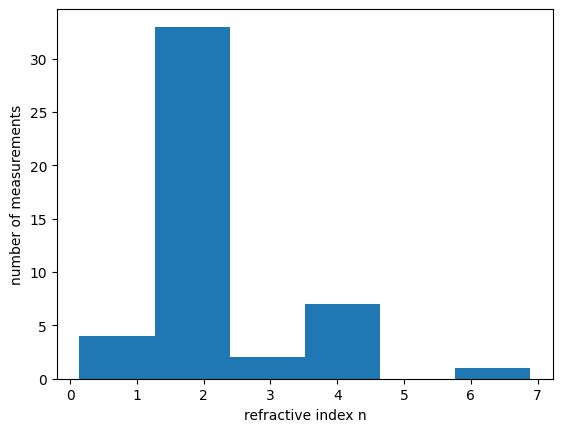

In [10]:
fig, ax = plt.subplots()
ax.hist(table['n'], bins=6)
ax.set_xlabel('refractive index n')
ax.set_ylabel('number of measurements')

Most measurements fall between 1.27 and 2.39.
The value near 6.89 is silicon in the infrared.
`bins=` sets the number of intervals.
The square root of the number of observations is a reasonable starting point, so we'll use six bins for 47 values.

`ax.bar` takes one height per category.
`ax.hist` takes one array and does the counting itself.

### [Check your understanding]

1. Compute silicon's reflectance and store it in `si` under the name `R`.
2. Show the first few rows and check that the new column is there.
3. Make a `fig, ax` and plot `si['R']` against silicon's wavelengths, with a `label=`.
4. Add BK7 to the same figure with its own `label=`, label both axes, and draw the legend.
5. Which of the two reflects more, and does it do so everywhere?

# A ratio of two columns

The depth at which light has faded to about a third of what entered is

$$d = \frac{\lambda}{4 \pi k}$$

In [11]:
depth_gold = au['wavelength_um'] / (4 * np.pi * au['k'])
depth_silicon = si['wavelength_um'] / (4 * np.pi * si['k'])

print(depth_gold)

0     0.012586
1     0.012669
2     0.012346
3     0.012242
4     0.011868
5     0.012676
6     0.014567
7     0.016201
8     0.020288
9     0.016180
10    0.013245
11    0.012109
12    0.011186
dtype: float64


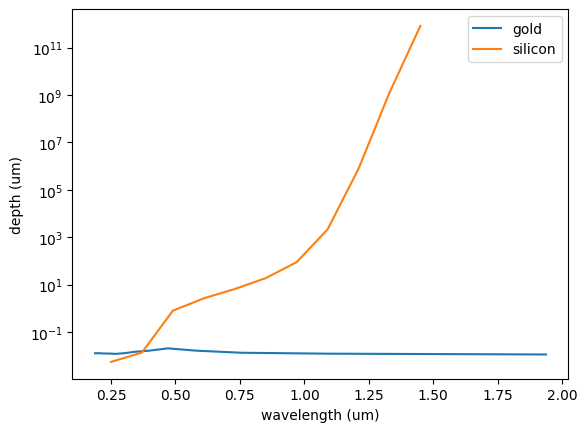

In [12]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], depth_gold, label='gold')
ax.plot(si['wavelength_um'], depth_silicon, label='silicon')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('depth (um)')
ax.set_yscale('log')
ax.legend()

Gold's penetration depth is about 13 nanometers in red light.
Silicon's values span fourteen orders of magnitude, so this comparison needs a log axis.

## Dividing by zero

The recorded $k$ values for fused silica are zero.

In [13]:
depth_silica = silica['wavelength_um'] / (4 * np.pi * silica['k'])

print(depth_silica.head())

0    inf
1    inf
2    inf
3    inf
4    inf
dtype: float64


`inf` represents infinity.
NumPy returns it for a nonzero value divided by zero.
Ordinary Python arithmetic would raise an error.
In this model, zero absorption gives an infinite penetration depth.

> Note: a column of exact zeros is usually a gap in the measurement rather than a perfect material.
> Real fused silica absorbs past about 4 um, and this file doesn't record it.

# Values we choose: `np.linspace`

To predict transmission as a function of thickness, first choose the thicknesses to evaluate.

In [14]:
thickness_um = np.linspace(0, 20, 100)

print(thickness_um[:5])
print(len(thickness_um))

[0.         0.2020202  0.4040404  0.60606061 0.80808081]
100


`np.linspace` takes a start, a stop and a count.
It returns that many evenly spaced values, with both ends included.

Here 100 points gives enough resolution for a smooth curve.

## A step instead of a count: `np.arange`

Use `np.arange` when the spacing matters.
It takes a start, a stop and a step.

In [15]:
print(np.arange(0, 20, 2.5))

[ 0.   2.5  5.   7.5 10.  12.5 15.  17.5]


`np.arange` stops before the stop value.
`np.linspace` includes both endpoints.
Use `np.linspace` to request a number of points and `np.arange` to request a step size.

# Exponential decay: `np.exp`

`np.exp` applies $e^x$ elementwise.
Transmission through an absorbing material decays exponentially with thickness:

$$T = e^{-4 \pi k t / \lambda}$$

Text(0, 0.5, 'fraction still traveling')

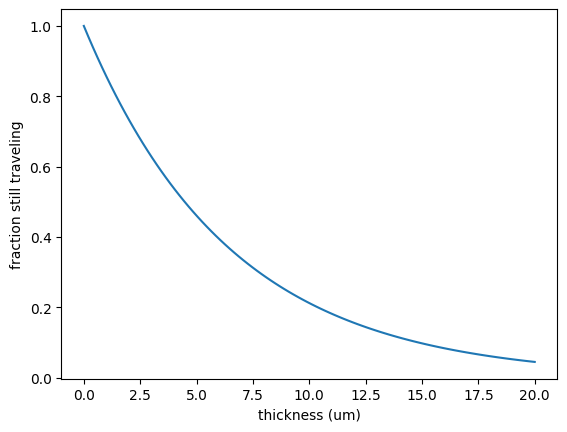

In [16]:
wavelength_um = 0.73
k_red = 0.009

T = np.exp(-4 * np.pi * k_red * thickness_um / wavelength_um)

fig, ax = plt.subplots()
ax.plot(thickness_um, T)
ax.set_xlabel('thickness (um)')
ax.set_ylabel('fraction still traveling')

For silicon at 0.73 um, a detector only a few micrometers thick would transmit most of the light.

## Marking a level: `ax.axhline`

The depth $d$ was defined as where the light has faded to $1/e$ of what entered, which is about 0.37.

`ax.axhline` draws a horizontal line all the way across the axes at a y value we give it, so we can see where the curve crosses that level.

Text(0, 0.5, 'fraction still traveling')

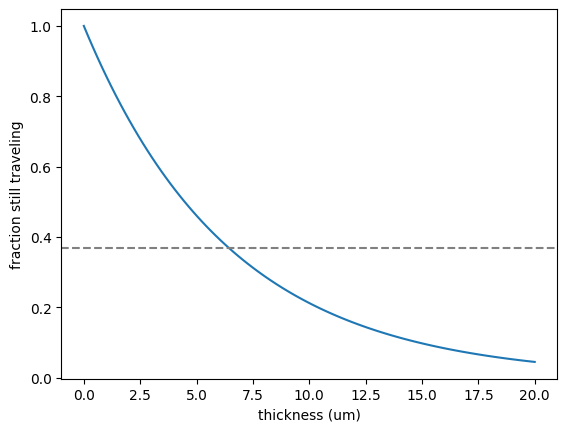

In [17]:
fig, ax = plt.subplots()
ax.plot(thickness_um, T)
ax.axhline(1 / np.e, color='gray', linestyle='--')
ax.set_xlabel('thickness (um)')
ax.set_ylabel('fraction still traveling')

The curve crosses $1/e$ near 6.5 um.

In [18]:
print(0.73 / (4 * np.pi * 0.009))

6.454617136504645


The penetration-depth formula gives the same value.

> Note: `ax.axvline` does the same thing vertically, at an x value.

### [Check your understanding]

1. Make a thickness axis from 0 to 100 nanometers with `np.linspace`, working in micrometers so the units match.
2. Compute the transmission through gold at red light, using $k = 4.5$ and the same 0.73 um.
3. Plot it with both axes labeled, and add the $1/e$ line with `ax.axhline`.
4. Read the crossing off the figure, then compute $\lambda / 4 \pi k$ and check that the two agree.
5. Gold's depth is smaller than silicon's by a factor of a few hundred. Which of $k$ or $\lambda$ is responsible?

# Styling a line

`color=` overrides matplotlib's default color sequence.

Text(0, 0.5, 'reflectance R')

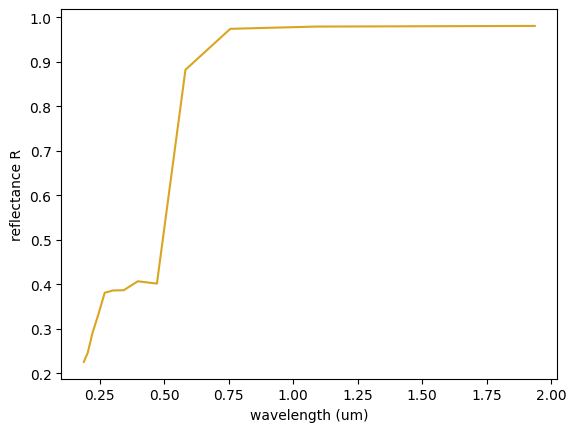

In [19]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, color='goldenrod')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')

`color=` takes a name like `'goldenrod'`, `'gray'` or `'black'`, and matplotlib knows several hundred of them.

`linestyle=` changes the line itself: `'-'` is solid, `'--'` is dashed, `':'` is dotted.

Text(0, 0.5, 'reflectance R')

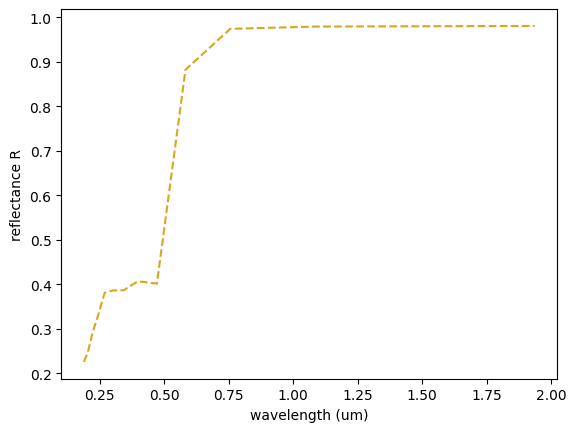

In [20]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, color='goldenrod', linestyle='--')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')

## Markers show where the data is

`marker=` puts a symbol at every value in the arrays.
`'o'` is a filled circle, `'s'` a square, `'^'` a triangle.

Text(0, 0.5, 'reflectance R')

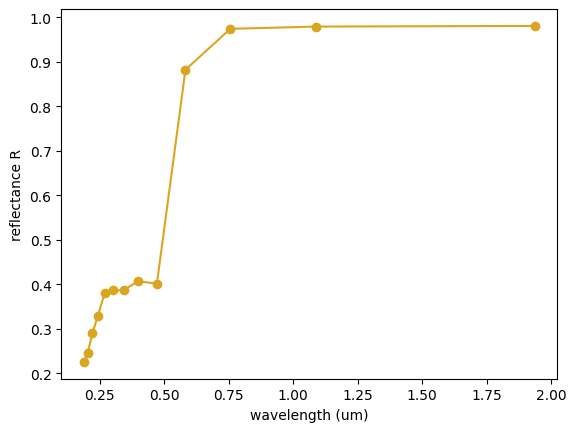

In [21]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, color='goldenrod', marker='o')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')

The markers make the measured wavelengths visible.

In [22]:
print(len(au))

13


Gold has thirteen measured wavelengths.
The line connects them with straight segments.
There are no additional measurements between the markers.

> Note: `ax.scatter` from last lecture draws the markers without the line.
> `ax.plot` with a `marker=` draws both.

## Zooming in: `ax.set_xlim`

Visible light runs from about 0.4 to 0.7 um, a small slice of what this file covers.

`ax.set_xlim` sets the two ends of the x axis, and `ax.set_ylim` does the same vertically.

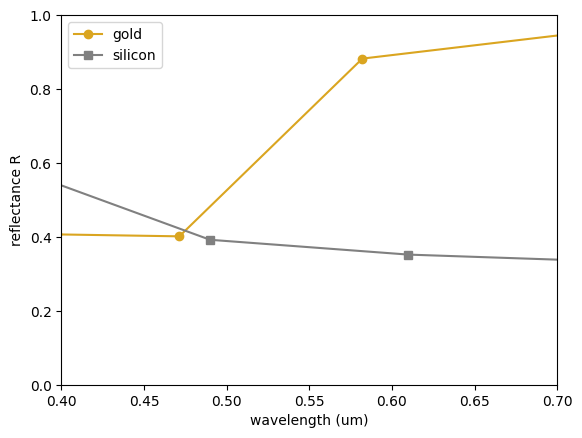

In [23]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, color='goldenrod', marker='o', label='gold')
ax.plot(si['wavelength_um'], R_silicon, color='gray', marker='s', label='silicon')
ax.set_xlim(0.4, 0.7)
ax.set_ylim(0, 1)
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')
ax.legend()

Axis limits change the displayed range, not the data.

Across the visible range gold climbs from about 0.4 to 0.95, which is why gold looks yellow: it sends back the red and the green and keeps most of the blue.

Silicon stays flat and gray at about 0.35.

# Two panels in one figure

Show reflectance and penetration depth side by side with `plt.subplots(rows, columns)`.
With more than one panel, `plt.subplots` returns an array of axes.

(2,)


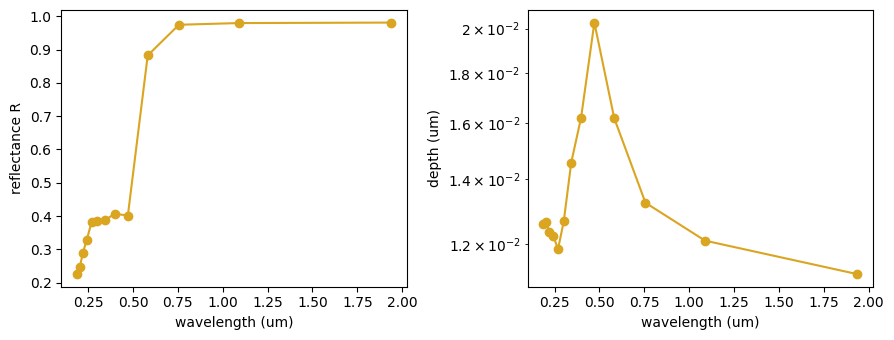

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

print(axes.shape)

axes[0].plot(au['wavelength_um'], R_gold, color='goldenrod', marker='o')
axes[0].set_xlabel('wavelength (um)')
axes[0].set_ylabel('reflectance R')

axes[1].plot(au['wavelength_um'], depth_gold, color='goldenrod', marker='o')
axes[1].set_yscale('log')
axes[1].set_xlabel('wavelength (um)')
axes[1].set_ylabel('depth (um)')

fig.tight_layout()

Use an index to select a panel from `axes`.
Each panel supports the same plotting methods as `ax`.
`figsize=(9, 3.5)` is the width and height in inches.
`fig.tight_layout()` spaces the boxes so the labels don't collide.

On the left, gold sends back 98% of infrared light.
On the right, the little that does get in stops within about 13 nanometers.

# Summary

* An expression over two columns gives a new column of the same length.
* Assigning it into the table under a new name adds a column to the table.
* `ax.bar` charts a quantity measured on categories.
* `ax.hist` takes one array, sorts it into `bins=` bins, and counts.
* `color=`, `linestyle=` and `marker=` set how a line is drawn, and markers show how many measurements are actually behind it.
* `ax.set_xlim` and `ax.set_ylim` change the window without changing the data.
* NumPy returns `inf` for division by zero instead of raising.
* `np.linspace(start, stop, count)` makes evenly spaced values we choose, and `np.arange(start, stop, step)` sets the spacing instead of the count.
* `np.exp` raises $e$ to every entry.
* `ax.axhline` marks a level across a figure.
* `plt.subplots(rows, cols)` returns an array of axes, one per panel.

Gold reflects 98% of infrared light and lets almost none of it in, which is what a telescope mirror is for.

## Further reading

* The data: [Polyanskiy, *Scientific Data* **11**, 94 (2024)](https://doi.org/10.1038/s41597-023-02898-2), the refractiveindex.info database, CC BY 4.0. Browse it at [refractiveindex.info](https://refractiveindex.info).
* [Fresnel equations](https://en.wikipedia.org/wiki/Fresnel_equations), where the reflectance formula comes from, and what it looks like at other angles.